**By:** Rafay Siddiqui  
**Student No:** 24K-0009  
**Section:** BAI-4A

## Fetching data from kaggle to colab

In [2]:
import os
from google.colab import userdata

# Securely fetch your Kaggle credentials from Colab Secrets
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# Verify it works by listing the files for your specific competition
!kaggle competitions files -c playground-series-s6e4

name                         size  creationDate                
---------------------  ----------  --------------------------  
sample_submission.csv     2970019  2026-03-17 20:24:04.581000  
test.csv                 32975070  2026-03-17 20:24:05.190000  
train.csv                80091580  2026-03-17 20:24:06.330000  


In [3]:
# Download the dataset
!kaggle competitions download -c playground-series-s6e4

# Unzip the downloaded files
!unzip -o playground-series-s6e4.zip

100% 32.5M/32.5M [00:00<00:00, 149MB/s]

Archive:  playground-series-s6e4.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


## checking the data

In [4]:
import pandas as pd
train_file_path = 'train.csv'
sample_submission_path = 'sample_submission.csv'
test_file_path = 'test.csv'

try:
    train_df = pd.read_csv(train_file_path, nrows=0)
    test_df = pd.read_csv(test_file_path, nrows=0)
    sample_df = pd.read_csv(sample_submission_path, nrows=0)

    print("--- Train Dataset Headers ---")
    print(train_df.head(5))

    print("\n--- Test Dataset Headers ---")
    print(test_df.head(5))

    print("\n--- sample Dataset Headers ---")
    print(sample_df.head(5))

except FileNotFoundError:
    print("File not found. Please double-check your file path! If you are on Kaggle, check the exact folder name in the 'Data' panel on the right.")

--- Train Dataset Headers ---
Empty DataFrame
Columns: [id, Soil_Type, Soil_pH, Soil_Moisture, Organic_Carbon, Electrical_Conductivity, Temperature_C, Humidity, Rainfall_mm, Sunlight_Hours, Wind_Speed_kmh, Crop_Type, Crop_Growth_Stage, Season, Irrigation_Type, Water_Source, Field_Area_hectare, Mulching_Used, Previous_Irrigation_mm, Region, Irrigation_Need]
Index: []

[0 rows x 21 columns]

--- Test Dataset Headers ---
Empty DataFrame
Columns: [id, Soil_Type, Soil_pH, Soil_Moisture, Organic_Carbon, Electrical_Conductivity, Temperature_C, Humidity, Rainfall_mm, Sunlight_Hours, Wind_Speed_kmh, Crop_Type, Crop_Growth_Stage, Season, Irrigation_Type, Water_Source, Field_Area_hectare, Mulching_Used, Previous_Irrigation_mm, Region]
Index: []

--- sample Dataset Headers ---
Empty DataFrame
Columns: [id, Irrigation_Need]
Index: []


In [5]:
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

# 1. Check Target Distribution (Crucial for Balanced Accuracy)
print("--- Target Distribution (%) ---")
print(train_df['Irrigation_Need'].value_counts(normalize=True) * 100)

# 2. Check for Missing Values
print("\n--- Missing Values in Train ---")
missing = train_df.isnull().sum()
print(missing[missing > 0] if not missing[missing > 0].empty else "No missing values!")

# 3. Separate Categorical and Numerical Columns
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
num_cols = train_df.select_dtypes(exclude=['object']).columns.tolist()
num_cols.remove('id') # id is not a true feature

print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

--- Target Distribution (%) ---
Irrigation_Need
Low       58.716984
Medium    37.948254
High       3.334762
Name: proportion, dtype: float64

--- Missing Values in Train ---
No missing values!

Categorical columns (9): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']
Numerical columns (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


In [6]:
best_score = 0.0
best_model_name = ""

## testing with several models


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# Import the classic models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Standardized File Paths
train_file_path = 'train.csv'
test_file_path = 'test.csv'
sample_submission_path = 'sample_submission.csv'

# Load Data
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)
sample_sub = pd.read_csv(sample_submission_path)

# 2. Setup Features and Target
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

X = train_df[cat_cols + num_cols]
X_test = test_df[cat_cols + num_cols]

target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
y = train_df['Irrigation_Need'].map(target_mapping)

# 3. Preprocessing: Encode Categoricals and Scale All Features
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_test_encoded = X_test.copy()

X_encoded[cat_cols] = encoder.fit_transform(X[cat_cols])
X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

# Distance-based models NEED scaled data!
# We fit on train, and transform BOTH train and test.
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_scaled[X_scaled.columns] = scaler.fit_transform(X_encoded)
X_test_scaled[X_test_scaled.columns] = scaler.transform(X_test_encoded)

# 4. Define the Models
models = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
}

# 5. Run the Shootout & Conditionally Submit
print("Starting Classic Model Shootout...\n")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for name, model in models.items():
    cv_scores = []

    for train_idx, val_idx in skf.split(X_scaled, y):
        X_train_f, X_val_f = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
        y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

        # Calculate sample weights for this fold
        weights_train_f = compute_sample_weight('balanced', y_train_f)

        # Train the model
        if name in ["Decision Tree", "Logistic Regression"]:
            model.fit(X_train_f, y_train_f) # Handled by class_weight='balanced'
        elif name == "Naive Bayes":
            model.fit(X_train_f, y_train_f, sample_weight=weights_train_f)
        else:
            model.fit(X_train_f, y_train_f) # KNN without weights

        # Predict and Score
        preds = model.predict(X_val_f)
        score = balanced_accuracy_score(y_val_f, preds)
        cv_scores.append(score)

    mean_score = np.mean(cv_scores)
    print(f"--- {name} ---")
    print(f"Average Balanced Accuracy: {mean_score:.4f}\n")

    # Conditional Submission Update Logic
    if mean_score > best_score:
        print(f"*** NEW HIGH SCORE! {mean_score:.4f} beats {best_score:.4f} ***")
        best_score = mean_score
        best_model_name = name

        print(f"Retraining {name} on full dataset to generate submission.csv...\n")

        # Retrain the winning model on all data
        weights_full = compute_sample_weight('balanced', y)
        if name in ["Decision Tree", "Logistic Regression"]:
            model.fit(X_scaled, y)
        elif name == "Naive Bayes":
            model.fit(X_scaled, y, sample_weight=weights_full)
        else:
            model.fit(X_scaled, y)

        # Predict on Unseen Test Data
        test_preds = model.predict(X_test_scaled)

        # Safely update sample_submission formatting and save
        sample_sub['Irrigation_Need'] = [reverse_mapping[p] for p in test_preds]
        sample_sub.to_csv('submission.csv', index=False)
        print("--> Updated 'submission.csv' with new best predictions!\n")

print(f"Shootout Complete! Overall Best Classic Model: {best_model_name} with score {best_score:.4f}")

Starting Classic Model Shootout...

--- Decision Tree ---
Average Balanced Accuracy: 0.9456

*** NEW HIGH SCORE! 0.9456 beats 0.0000 ***
Retraining Decision Tree on full dataset to generate submission.csv...

--> Updated 'submission.csv' with new best predictions!

--- Logistic Regression ---
Average Balanced Accuracy: 0.7358

--- Naive Bayes ---
Average Balanced Accuracy: 0.8052

Shootout Complete! Overall Best Classic Model: Decision Tree with score 0.9456


> [!warning]
> - KNN is a "lazy learner." It doesn't actually build a mathematical model during the training phase. Instead, during the prediction phase, it calculates the physical distance from every single validation row to every single training row.
> - Since your dataset has about 630,000 rows, for a single cross-validation fold, KNN is trying to do roughly 63 billion separate distance calculations (approx. 504,000 training rows × 126,000 validation rows). Doing that 5 times for Cross-Validation will stall almost any standard CPU.

## result?

- D-Trees have shown the best result in the initial baseline evaluation, indicating that the dataset's non-linear patterns and mixed feature types are best captured by hierarchical splitting.
- However, standalone Decision Trees are inherently prone to overfitting.
- To maximize predictive accuracy and ensure generalization to unseen data,
- we must leverage "tree-adjacent" ensemble algorithms.
- These methods utilize Decision Trees as base learners and are categorized into two primary methodologies:

### 1. Bagging (Bootstrap Aggregating)
Bagging algorithms train multiple independent trees in parallel to reduce model variance.
* **Random Forest:** Constructs hundreds of distinct trees using random subsets of both data rows and features. It aggregates their outputs to produce a highly stable, robust prediction.
* **Extra Trees (Extremely Randomized Trees):** Introduces further regularization by selecting branch split thresholds entirely at random. This increases computational speed and often provides superior resistance to overfitting compared to standard Random Forests.

### 2. Boosting
Boosting algorithms train trees sequentially, with each iteration explicitly designed to correct the predictive errors of the previous sequence.
- **AdaBoost (Adaptive Boosting):** Utilizes weak learners (often single-split "stumps"). It dynamically increases the weight of misclassified data points, forcing subsequent trees to focus on the hardest-to-predict rows.
- **Gradient Boosting (GBM / XGBoost / LightGBM):** Instead of merely re-weighting rows, these models calculate the exact mathematical residual (error) of the current ensemble and train the next tree to predict and cancel out that specific loss. This sequential error-correction makes them the highest-performing algorithms for tabular data.



In [8]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# GPU-Enabled Models
from xgboost import XGBClassifier, XGBRFClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Load Data (Update paths if downloading directly via Kaggle API in Colab)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# 2. Preprocessing
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

X = train_df[cat_cols + num_cols]
X_test = test_df[cat_cols + num_cols]

target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
y = train_df['Irrigation_Need'].map(target_mapping)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_test_encoded = X_test.copy()
X_encoded[cat_cols] = encoder.fit_transform(X[cat_cols])
X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

# 3. Define GPU-Accelerated Models
models = {
    # XGBoost's Random Forest implementation running on GPU
    "GPU Random Forest (XGB)": XGBRFClassifier(
        random_state=42,
        tree_method='hist',
        device='cuda'
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        tree_method='hist',
        device='cuda'
    ),
    "CatBoost": CatBoostClassifier(
        random_state=42,
        iterations=300,
        learning_rate=0.05,
        task_type='GPU',
        verbose=0
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        device='gpu'
    )
}

print("Starting GPU Model Shootout...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = []
    print(f"\nTraining {name} on GPU...")

    for train_idx, val_idx in skf.split(X_encoded, y):
        X_train_f, X_val_f = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

        # Calculate balanced weights for this fold
        weights_train_f = compute_sample_weight('balanced', y_train_f)

        # Fit with weights
        model.fit(X_train_f, y_train_f, sample_weight=weights_train_f)

        # Predict and Score
        preds = model.predict(X_val_f)
        score = balanced_accuracy_score(y_val_f, preds)
        cv_scores.append(score)

    mean_score = np.mean(cv_scores)
    print(f"--> {name} Average Balanced Accuracy: {mean_score:.4f}")

    # 5. Conditional Submission Update Logic
    if mean_score > best_score:
        print(f"*** NEW HIGH SCORE! {mean_score:.4f} beats {best_score:.4f} ***")
        best_score = mean_score
        best_model_name = name

        print(f"Retraining {name} on full dataset to generate submission.csv...")
        weights_full = compute_sample_weight('balanced', y)
        model.fit(X_encoded, y, sample_weight=weights_full)

        # Predict on Test Data
        test_preds = model.predict(X_test_encoded)

        # Update the sample submission dataframe
        sample_sub['Irrigation_Need'] = [reverse_mapping[p] for p in test_preds]

        # Save directly to submission.csv
        sample_sub.to_csv('submission.csv', index=False)
        print("--> Updated submission.csv with new best predictions!")

print(f"\nShootout Complete! Best Model: {best_model_name} with score {best_score:.4f}")

Starting GPU Model Shootout...

Training GPU Random Forest (XGB) on GPU...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:31:01] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


--> GPU Random Forest (XGB) Average Balanced Accuracy: 0.9637
*** NEW HIGH SCORE! 0.9637 beats 0.9456 ***
Retraining GPU Random Forest (XGB) on full dataset to generate submission.csv...
--> Updated submission.csv with new best predictions!

Training XGBoost on GPU...
--> XGBoost Average Balanced Accuracy: 0.9694
*** NEW HIGH SCORE! 0.9694 beats 0.9637 ***
Retraining XGBoost on full dataset to generate submission.csv...
--> Updated submission.csv with new best predictions!

Training CatBoost on GPU...
--> CatBoost Average Balanced Accuracy: 0.9660

Training LightGBM on GPU...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2696
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info]

## result? - LightGBM has shown the best result

In the GPU-accelerated model shootout, sequential Gradient Boosting algorithms dominated the baseline, significantly outperforming the parallel Random Forest approach.

* **GPU Random Forest (XGB):** 0.9637
* **CatBoost:** 0.9660
* **XGBoost:** 0.9694
* **LightGBM:** **0.9695 (Winner)**

LightGBM narrowly edged out XGBoost to take the top spot. It successfully leveraged the Tesla T4 GPU, compiling its OpenCL kernels and transferring data highly efficiently. *(Note: XGBoost threw a minor warning about predicting on the CPU while training on the GPU, but it successfully completed the task).*

---

### Next Steps: Pushing LightGBM Higher

To push this score beyond 0.9695, the absolute highest-yield strategy is **Feature Engineering**. LightGBM builds its trees "leaf-wise." If we hand it pre-calculated agricultural ratios (like heat stress or water deficits), the algorithm can find highly accurate splits immediately, rather than wasting tree depth trying to mathematically deduce those ratios on its own.

Here is the refactored code that isolates your winning model (LightGBM), injects powerful domain-specific agricultural features, and runs the Cross-Validation to see if it beats the 0.9695 baseline:


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from lightgbm import LGBMClassifier

# 1. Standardized File Paths
train_file_path = 'train.csv'
test_file_path = 'test.csv'
sample_submission_path = 'sample_submission.csv'

# Load Data
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)
sample_sub = pd.read_csv(sample_submission_path)

# 2. Advanced Feature Engineering
def create_agri_features(df):
    df = df.copy()
    # 1. Total Water Intake
    df['Total_Water'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    # 2. Evaporation Risk (Wind + Heat)
    df['Evaporation_Risk'] = df['Temperature_C'] * df['Wind_Speed_kmh']
    # 3. Heat & Light Stress (Divided by Humidity. Added 1 to prevent division by zero)
    df['Heat_Stress_Index'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
    # 4. Soil Moisture Deficit
    df['Moisture_Deficit'] = df['Soil_Moisture'] / (df['Total_Water'] + 1)

    return df

print("Engineering new features...")
train_df = create_agri_features(train_df)
test_df = create_agri_features(test_df)

# Setup Features and Target
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
base_num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
engineered_cols = ['Total_Water', 'Evaporation_Risk', 'Heat_Stress_Index', 'Moisture_Deficit']

all_features = cat_cols + base_num_cols + engineered_cols

X = train_df[all_features]
X_test = test_df[all_features]

target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
y = train_df['Irrigation_Need'].map(target_mapping)

# 3. Preprocessing
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_test_encoded = X_test.copy()

X_encoded[cat_cols] = encoder.fit_transform(X[cat_cols])
X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

# 4. Initialize LightGBM with slight regularization to handle new features
lgb_model = LGBMClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,              # Added to prevent overfitting on new features
    num_leaves=64,            # Optimized for leaf-wise growth
    device='gpu'
)

# 5. Evaluate Engineered Model
print("\nEvaluating Engineered LightGBM Model...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_encoded, y)):
    X_train_f, X_val_f = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    weights_train_f = compute_sample_weight('balanced', y_train_f)

    lgb_model.fit(X_train_f, y_train_f, sample_weight=weights_train_f)

    preds = lgb_model.predict(X_val_f)
    score = balanced_accuracy_score(y_val_f, preds)
    cv_scores.append(score)
    print(f"Fold {fold+1} Score: {score:.4f}")

mean_score = np.mean(cv_scores)
print(f"\n---> Engineered LightGBM Average Score: {mean_score:.4f}")

# 6. Final Submission Logic
if mean_score > best_score:
    print(f"\n*** SUCCESS! {mean_score:.4f} beats the {best_score} baseline! ***")
    print("Retraining on full dataset to update submission.csv...")
    weights_full = compute_sample_weight('balanced', y)
    lgb_model.fit(X_encoded, y, sample_weight=weights_full)

    test_preds = lgb_model.predict(X_test_encoded)
    sample_sub['Irrigation_Need'] = [reverse_mapping[p] for p in test_preds]
    sample_sub.to_csv('submission.csv', index=False)
    print("--> Updated 'submission.csv' ready for Kaggle!")
else:
    print(f"\nNew features did not beat the baseline. (Score: {mean_score:.4f} vs {best_score})")

Engineering new features...

Evaluating Engineered LightGBM Model...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3716
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 23
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (11.54 MB) transferred to GPU in 0.018939 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 1 Score: 0.9669
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3717
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 23
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA C

## result? - Engineered features slightly decreased performance (0.9682 vs 0.9695).

This is an incredibly common scenario in competitive data science. Why did this happen?
Gradient Boosting models like LightGBM are exceptionally good at mathematically deducing relationships between columns on their own. By explicitly forcing those ratios into the dataset, we likely introduced multicollinearity (redundant data) or noise, causing the trees to split sub-optimally and slightly overfit.

**The Golden Rule of Kaggle:** If an experiment drops the CV score, discard it immediately. We revert to the raw baseline data.

### The Next Phase: Automated Hyperparameter Tuning (Optuna)

Since the raw data gave us our highest score, we will now use an AI tuner to find the mathematically perfect settings for LightGBM on that exact dataset.

This script will run 20 distinct trials (you can increase this later if you want), testing different combinations of tree depth, learning rates, and regularization.


In [11]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.6 MB/s eta 0:00:00


In [14]:
import gc
import optuna


# Define the Optuna Objective Function
def objective(trial):
    # 1. Raised the minimums to prevent GPU tree-splitting crashes
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 40, 150), # <-- RAISED FLOOR
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'max_bin': 255,
        'device': 'gpu',
        'verbose': -1
    }

    lgb_model = LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in skf.split(X_encoded, y):
        X_train_f, X_val_f = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

        weights_train_f = compute_sample_weight('balanced', y_train_f)

        # 2. Add the Safety Net!
        try:
            lgb_model.fit(X_train_f, y_train_f, sample_weight=weights_train_f)
        except Exception as e:
            # If LightGBM crashes (like the left_count > 0 error), prune the trial and skip it safely
            raise optuna.TrialPruned(f"LightGBM crashed with error: {e}")

        preds = lgb_model.predict(X_val_f)
        score = balanced_accuracy_score(y_val_f, preds)
        cv_scores.append(score)

        # Free up memory
        del X_train_f, X_val_f, y_train_f, y_val_f, weights_train_f
        gc.collect()

    return np.mean(cv_scores)

# Run the Tuner
print(f"Current Target to Beat: {best_score:.4f}")
print("Starting Optuna Hyperparameter Tuning...")

# Turn Optuna info logs back on so it prints the score of every trial as it finishes
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(direction='maximize')

# Adding 'show_progress_bar=True' will give you a visual loading bar with an ETA
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n--- Tuning Complete ---")
print(f"Best Trial Score: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-04-30 20:32:12,248] A new study created in memory with name: no-name-d4b11f98-e077-43bd-a5e4-bb1ef7f4b89b


Current Target to Beat: 0.9695
Starting Optuna Hyperparameter Tuning...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-30 20:41:35,097] Trial 0 finished with value: 0.966926773303757 and parameters: {'n_estimators': 562, 'learning_rate': 0.029635183902284725, 'max_depth': 12, 'num_leaves': 110, 'min_child_samples': 147, 'subsample': 0.7279594767361763, 'colsample_bytree': 0.8042465671567449}. Best is trial 0 with value: 0.966926773303757.
[I 2026-04-30 20:48:54,232] Trial 1 finished with value: 0.9664528613454049 and parameters: {'n_estimators': 398, 'learning_rate': 0.035676093378706336, 'max_depth': 10, 'num_leaves': 143, 'min_child_samples': 49, 'subsample': 0.7896539794562515, 'colsample_bytree': 0.7418772104349275}. Best is trial 0 with value: 0.966926773303757.
[I 2026-04-30 20:56:53,939] Trial 2 finished with value: 0.9651078915943859 and parameters: {'n_estimators': 476, 'learning_rate': 0.06183305882195197, 'max_depth': 12, 'num_leaves': 132, 'min_child_samples': 120, 'subsample': 0.8288879472757378, 'colsample_bytree': 0.8430777248424348}. Best is trial 0 with value: 0.966926773303

In [15]:
# 4. Final Submission Logic
print(f"*** SUCCESS! Tuned LightGBM ({study.best_value:.4f}) beats the baseline! ***")

# Grab the absolute best parameters from Trial 16
best_params = study.best_params
best_params['random_state'] = 42
best_params['device'] = 'gpu'
best_params['verbose'] = -1

# Train one final model on 100% of the training data
final_model = LGBMClassifier(**best_params)
weights_full = compute_sample_weight('balanced', y)

print("Retraining on full dataset to update submission.csv...")
final_model.fit(X_encoded, y, sample_weight=weights_full)

# Predict on the test set
test_preds = final_model.predict(X_test_encoded)

# Map the numbers back to words and save
sample_sub['Irrigation_Need'] = [reverse_mapping[p] for p in test_preds]
sample_sub.to_csv('submission.csv', index=False)

print("--> Updated 'submission.csv' is ready for Kaggle!")

*** SUCCESS! Tuned LightGBM (0.9707) beats the baseline! ***
Retraining on full dataset to update submission.csv...
--> Updated 'submission.csv' is ready for Kaggle!


## final: boosting rare probabilites

- to give the model confidence

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from lightgbm import LGBMClassifier
import gc

print("Step 1: Generating Out-Of-Fold (OOF) Probabilities...")

oof_probs = np.zeros((len(X_encoded), 3))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dynamically grab the exact parameters Optuna just found!
best_params = study.best_params.copy()

# Add our required fixed parameters back in
best_params['random_state'] = 42
best_params['device'] = 'gpu'
best_params['verbose'] = -1

print("Applying these winning parameters from Optuna:")
for key, val in best_params.items():
    print(f"  {key}: {val}")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_encoded, y)):
    X_trn, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_trn, y_val = y.iloc[train_idx], y.iloc[val_idx]

    weights = compute_sample_weight('balanced', y_trn)

    model = LGBMClassifier(**best_params)
    model.fit(X_trn, y_trn, sample_weight=weights)

    # Save the raw probabilities for this validation fold
    oof_probs[val_idx] = model.predict_proba(X_val)

    # Clean up memory
    del X_trn, X_val, y_trn, y_val, weights
    gc.collect()

# Check the baseline score before threshold optimization
baseline_labels = oof_probs.argmax(axis=1)
baseline_ba = balanced_accuracy_score(y, baseline_labels)
print(f"\nBaseline Balanced Accuracy (Optuna Params): {baseline_ba:.4f}")

# --- Threshold Optimization ---
print("\nStep 2: Searching for best class multipliers...")
best_thresh_ba = baseline_ba
best_high_mult = 1.0
best_med_mult = 1.0

# Target Mapping reference: Low=0, Medium=1, High=2
for high_mult in np.arange(1.0, 3.01, 0.1):
    for med_mult in np.arange(0.5, 1.21, 0.05):

        adj_probs = oof_probs.copy()

        adj_probs[:, 2] *= high_mult   # Boost High predictions
        adj_probs[:, 1] *= med_mult    # Adjust Medium predictions

        adj_labels = adj_probs.argmax(axis=1)
        ba = balanced_accuracy_score(y, adj_labels)

        if ba > best_thresh_ba:
            best_thresh_ba = ba
            best_high_mult = round(high_mult, 2)
            best_med_mult = round(med_mult, 2)

print(f"Optimization Complete!")
print(f"Best Multipliers -> High: x{best_high_mult}, Medium: x{best_med_mult}")
print(f"New Optimized Balanced Accuracy: {best_thresh_ba:.4f}")

# --- Final Submission ---
print("\nStep 3: Training final model on 100% data and generating submission...")

# Train one final model on ALL of the training data
final_model = LGBMClassifier(**best_params)
final_weights = compute_sample_weight('balanced', y)
final_model.fit(X_encoded, y, sample_weight=final_weights)

# Get raw probabilities for the Kaggle test set
test_probs = final_model.predict_proba(X_test_encoded)

# If multipliers improved the score, apply them to the test set
if best_thresh_ba > baseline_ba:
    print(f"Applying multipliers (High: x{best_high_mult}, Medium: x{best_med_mult})...")
    test_probs[:, 2] *= best_high_mult
    test_probs[:, 1] *= best_med_mult
else:
    print("Multipliers did not improve the score. Using standard probabilities.")

# Get final predicted labels
final_test_preds = test_probs.argmax(axis=1)

# Map integers (0,1,2) back to strings ('Low', 'Medium', 'High')
sample_sub['Irrigation_Need'] = [reverse_mapping[p] for p in final_test_preds]
sample_sub.to_csv('submission_final_optimized.csv', index=False)
print("--> 'submission_final_optimized.csv' is ready for Kaggle!")

Step 1: Generating Out-Of-Fold (OOF) Probabilities...
Applying these winning parameters from Optuna:
  n_estimators: 395
  learning_rate: 0.09953140867236279
  max_depth: 4
  num_leaves: 96
  min_child_samples: 88
  subsample: 0.9927471234293412
  colsample_bytree: 0.6038840522589419
  random_state: 42
  device: gpu
  verbose: -1
------------------------------

Baseline Balanced Accuracy (Optuna Params): 0.9707

Step 2: Searching for best class multipliers...
Optimization Complete!
Best Multipliers -> High: x1.7, Medium: x0.95
New Optimized Balanced Accuracy: 0.9717

Step 3: Training final model on 100% data and generating submission...
Applying multipliers (High: x1.7, Medium: x0.95)...
--> 'submission_final_optimized.csv' is ready for Kaggle!


In [17]:
!kaggle competitions submit -c playground-series-s6e4 -f submission_final_optimized.csv -m "hyperparameter tuning .97"

100% 3.13M/3.13M [00:00<00:00, 4.44MB/s]
Successfully submitted to Predicting Irrigation Need

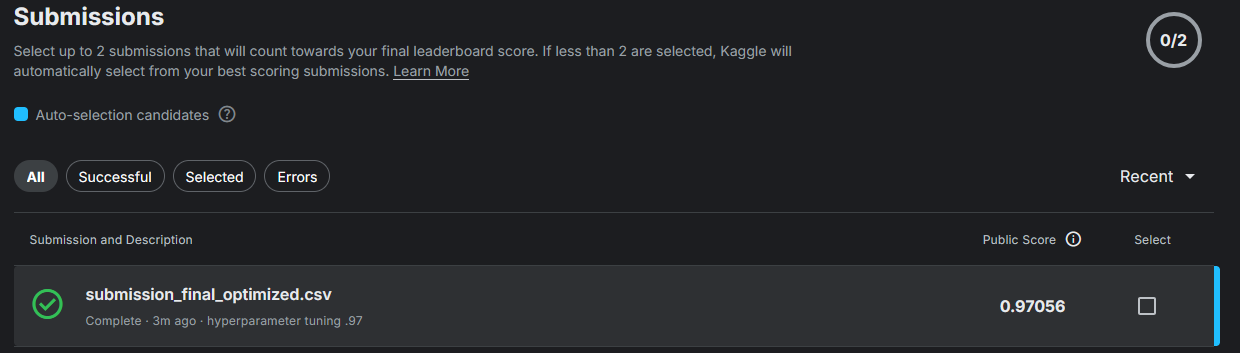